In [1]:
pip install torch torchvision scikit-learn numpy matplotlib


Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

#Load and prepare MNIST (digits 0 vs 1)
mnist = fetch_openml("mnist_784", version=1, as_frame=False)
X = mnist["data"].astype(np.float32) / 255.0
y = mnist["target"].astype(np.int32)

mask = (y == 0) | (y == 1)
X = X[mask]
y = y[mask]
y = np.where(y == 0, -1, 1).astype(np.float32)

#Partition data across 10 nodes
num_nodes = 10
X_parts = np.array_split(X, num_nodes)
y_parts = np.array_split(y, num_nodes)

#Define a simple primal SVM model
class PrimalSVM(nn.Module):
    def __init__(self, input_dim=784):
        super().__init__()
        self.linear = nn.Linear(input_dim, 1, bias=True)

    def forward(self, x):
        return self.linear(x)

#Initialize models and optimizers
nodes = []
for _ in range(num_nodes):
    model = PrimalSVM()
    optimizer = optim.SGD(model.parameters(), lr=0.1)
    nodes.append({"model": model, "optimizer": optimizer})

#Gossip function for ring topology
def gossip_ring(models):
    new_weights = []
    for i in range(num_nodes):
        prev_idx = (i - 1) % num_nodes
        next_idx = (i + 1) % num_nodes
        w_prev = list(models[prev_idx].parameters())[0].data
        w_curr = list(models[i].parameters())[0].data
        w_next = list(models[next_idx].parameters())[0].data
        averaged = (w_prev + w_curr + w_next) / 3.0
        new_weights.append(averaged.clone())
    # Apply averaged weights
    for i, model in enumerate(models):
        list(model.parameters())[0].data.copy_(new_weights[i])

#Training loop with gossip
for epoch in range(10):
    for node_id, node in enumerate(nodes):
        model = node["model"]
        optimizer = node["optimizer"]
        model.train()

        x = torch.FloatTensor(X_parts[node_id])
        y_true = torch.FloatTensor(y_parts[node_id]).view(-1, 1)

        outputs = model(x)
        hinge_loss = torch.clamp(1 - y_true * outputs, min=0)
        l2_reg = torch.norm(model.linear.weight) ** 2
        loss = torch.mean(hinge_loss) + 0.01 * l2_reg

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # Gossip step after each epoch
    gossip_ring([node["model"] for node in nodes])

#Evaluate final model (averaged)
final_weights = sum([node["model"].linear.weight.data for node in nodes]) / num_nodes
final_bias = sum([node["model"].linear.bias.data for node in nodes]) / num_nodes

#Test set evaluation
_, X_test, _, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_test_tensor = torch.FloatTensor(X_test)
logits = X_test_tensor @ final_weights.T + final_bias
preds = torch.sign(logits).squeeze().numpy()
acc = accuracy_score(y_test, preds)
print(f"Final Test Accuracy (Primal SVM, Gossip-P2PFL): {acc:.4f}")

Final Test Accuracy (Primal SVM, Gossip-P2PFL): 0.9986


In [3]:
# P2PFL Dual SVM (MNIST 0 vs 1) with Gossip Ring Topology using Local Linear Kernels

import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

#Load and prepare MNIST (digits 0 vs 1)
mnist = fetch_openml("mnist_784", version=1, as_frame=False)
X = mnist["data"].astype(np.float32) / 255.0
y = mnist["target"].astype(np.int32)

mask = (y == 0) | (y == 1)
X = X[mask]
y = y[mask]
y = np.where(y == 0, -1, 1).astype(np.float32)

#Partition data across  nodes
num_nodes = 10
X_parts = np.array_split(X, num_nodes)
y_parts = np.array_split(y, num_nodes)

#Initialize dual variables alpha at each node
alphas = [np.zeros(len(y_parts[i])) for i in range(num_nodes)]

#Define local linear kernel matrix computation
def compute_local_kernel(X):
    return X @ X.T

#Dual SVM local update function (coordinate ascent on hinge dual)
def dual_local_update(alpha, X, y, C=1.0, lr=0.001):
    K = compute_local_kernel(X)
    for i in range(len(alpha)):
        grad = 1 - y[i] * np.sum(alpha * y * K[:, i])
        alpha[i] += lr * grad
        alpha[i] = np.clip(alpha[i], 0, C)
    return alpha

#Gossip function (average alphas with ring neighbors)
def gossip_ring_dual(alphas):
    new_alphas = []
    for i in range(num_nodes):
        prev = (i - 1) % num_nodes
        nxt = (i + 1) % num_nodes
        a_avg = (alphas[prev] + alphas[i] + alphas[nxt]) / 3.0
        new_alphas.append(a_avg)
    return new_alphas

#Main dual SVM training loop with gossip
for epoch in range(10):
    for i in range(num_nodes):
        alphas[i] = dual_local_update(alphas[i], X_parts[i], y_parts[i], C=1.0, lr=0.001)
    alphas = gossip_ring_dual(alphas)

# 8. Reconstruct global weight vector (primal form) by combining local contributions
w_global = np.zeros(784)
for i in range(num_nodes):
    w_global += np.sum((alphas[i] * y_parts[i])[:, None] * X_parts[i], axis=0)

# 9. Evaluate on held-out test set
_, X_test, _, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
preds = np.sign(X_test @ w_global)
acc = accuracy_score(y_test, preds)
print(f"Final Test Accuracy (Dual SVM, Gossip-P2PFL): {acc:.4f}")

Final Test Accuracy (Dual SVM, Gossip-P2PFL): 0.9980


In [4]:
# P2PFL Dual SVM (MNIST 0 vs 1) with Gossip Ring Topology using Local Linear Kernels + Primal-Dual Gap

import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

#Load and prepare MNIST (digits 0 vs 1)
mnist = fetch_openml("mnist_784", version=1, as_frame=False)
X = mnist["data"].astype(np.float32) / 255.0
y = mnist["target"].astype(np.int32)

mask = (y == 0) | (y == 1)
X = X[mask]
y = y[mask]
y = np.where(y == 0, -1, 1).astype(np.float32)

#Partition data across nodes
num_nodes = 10
X_parts = np.array_split(X, num_nodes)
y_parts = np.array_split(y, num_nodes)

#Initialize dual variables alpha at each node
alphas = [np.zeros(len(y_parts[i])) for i in range(num_nodes)]

#Define local linear kernel matrix computation
def compute_local_kernel(X):
    return X @ X.T

#Dual SVM local update function
def dual_local_update(alpha, X, y, C=1.0, lr=0.001):
    K = compute_local_kernel(X)
    for i in range(len(alpha)):
        grad = 1 - y[i] * np.sum(alpha * y * K[:, i])
        alpha[i] += lr * grad
        alpha[i] = np.clip(alpha[i], 0, C)
    return alpha

# Gossip function (average alphas with ring neighbors)
def gossip_ring_dual(alphas):
    new_alphas = []
    for i in range(num_nodes):
        prev = (i - 1) % num_nodes
        nxt = (i + 1) % num_nodes
        a_avg = (alphas[prev] + alphas[i] + alphas[nxt]) / 3.0
        new_alphas.append(a_avg)
    return new_alphas

#Primal-dual gap function
def primal_dual_gap(alpha_all, X_all, y_all, C=1.0):
    alpha = np.concatenate(alpha_all)
    X = np.vstack(X_all)
    y = np.concatenate(y_all)
    K = X @ X.T
    w = np.sum((alpha * y)[:, None] * X, axis=0)
    primal = 0.5 * np.dot(w, w) + C * np.sum(np.maximum(0, 1 - y * (X @ w)))
    dual = np.sum(alpha) - 0.5 * np.sum(np.outer(alpha * y, alpha * y) * K)
    return primal - dual

#Main dual SVM training loop with gossip
for epoch in range(10):
    for i in range(num_nodes):
        alphas[i] = dual_local_update(alphas[i], X_parts[i], y_parts[i], C=1.0, lr=0.001)
    alphas = gossip_ring_dual(alphas)

    gap = primal_dual_gap(alphas, X_parts, y_parts, C=1.0)
    print(f"Epoch {epoch}: Primal-Dual Gap = {gap:.4f}")

# 9. Reconstruct global weight vector (primal form) by combining local contributions
w_global = np.zeros(784)
for i in range(num_nodes):
    w_global += np.sum((alphas[i] * y_parts[i])[:, None] * X_parts[i], axis=0)

# 10. Evaluate on held-out test set
_, X_test, _, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
preds = np.sign(X_test @ w_global)
acc = accuracy_score(y_test, preds)
print(f"Final Test Accuracy (Dual SVM, Gossip-P2PFL): {acc:.4f}")

Epoch 0: Primal-Dual Gap = 385.3055
Epoch 1: Primal-Dual Gap = 356.0223
Epoch 2: Primal-Dual Gap = 333.3792
Epoch 3: Primal-Dual Gap = 313.1203
Epoch 4: Primal-Dual Gap = 297.1141
Epoch 5: Primal-Dual Gap = 286.7570
Epoch 6: Primal-Dual Gap = 279.7625
Epoch 7: Primal-Dual Gap = 274.3242
Epoch 8: Primal-Dual Gap = 269.9940
Epoch 9: Primal-Dual Gap = 266.2387
Final Test Accuracy (Dual SVM, Gossip-P2PFL): 0.9980


Epoch 0: Primal = 373.2585, Dual = -12.0470, Gap = 385.3055, ||w_dual|| = 5.2371
Epoch 1: Primal = 344.6649, Dual = -11.3574, Gap = 356.0223, ||w_dual|| = 5.1200
Epoch 2: Primal = 322.8510, Dual = -10.5282, Gap = 333.3792, ||w_dual|| = 4.9562
Epoch 3: Primal = 303.0585, Dual = -10.0619, Gap = 313.1203, ||w_dual|| = 4.8613
Epoch 4: Primal = 287.3180, Dual = -9.7960, Gap = 297.1141, ||w_dual|| = 4.8070
Epoch 5: Primal = 277.0909, Dual = -9.6661, Gap = 286.7570, ||w_dual|| = 4.7813
Epoch 6: Primal = 270.1570, Dual = -9.6055, Gap = 279.7625, ||w_dual|| = 4.7702
Epoch 7: Primal = 264.7511, Dual = -9.5731, Gap = 274.3242, ||w_dual|| = 4.7650
Epoch 8: Primal = 260.4381, Dual = -9.5559, Gap = 269.9940, ||w_dual|| = 4.7628
Epoch 9: Primal = 256.6934, Dual = -9.5452, Gap = 266.2387, ||w_dual|| = 4.7618
Test Accuracy (Dual SVM): 0.9980
Test Accuracy (Primal SGD with Gossip): 0.9986


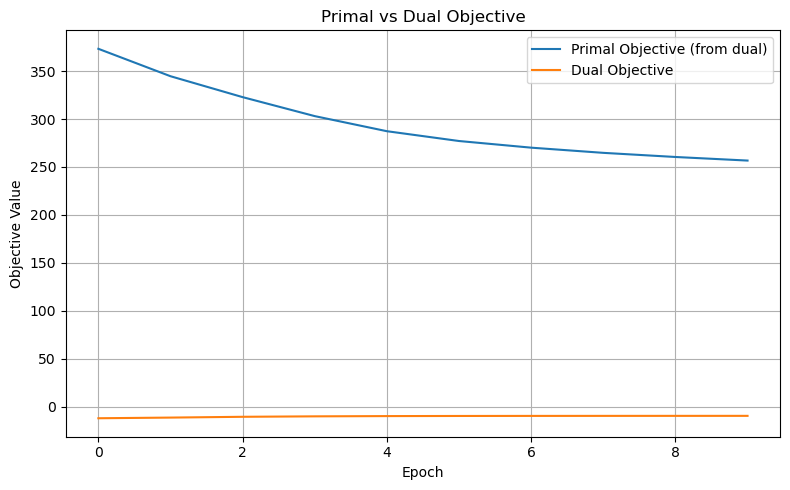

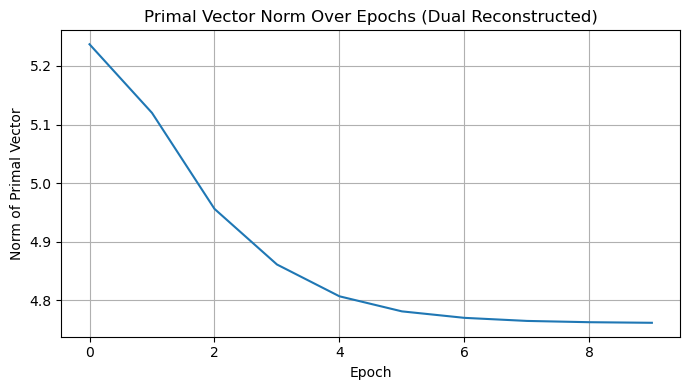

In [10]:
# P2PFL Dual + Primal SVM (MNIST 0 vs 1) with Gossip Ring Topology on Both Paths

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

#Load and prepare MNIST (digits 0 vs 1)
mnist = fetch_openml("mnist_784", version=1, as_frame=False)
X = mnist["data"].astype(np.float32) / 255.0
y = mnist["target"].astype(np.int32)

mask = (y == 0) | (y == 1)
X = X[mask]
y = y[mask]
y = np.where(y == 0, -1, 1).astype(np.float32)

#Partition data across nodes
num_nodes = 10
X_parts = np.array_split(X, num_nodes)
y_parts = np.array_split(y, num_nodes)

#Initialize dual variables alpha and primal weights at each node
alphas = [np.zeros(len(y_parts[i])) for i in range(num_nodes)]
w_primal_nodes = [np.zeros(X.shape[1]) for _ in range(num_nodes)]

#Compute local kernel matrix
def compute_local_kernel(X):
    return X @ X.T

#Dual SVM local update
def dual_local_update(alpha, X, y, C=1.0, lr=0.001):
    K = compute_local_kernel(X)
    for i in range(len(alpha)):
        grad = 1 - y[i] * np.sum(alpha * y * K[:, i])
        alpha[i] += lr * grad
        alpha[i] = np.clip(alpha[i], 0, C)
    return alpha

#Gossip ring for dual variables
def gossip_ring_dual(alphas):
    new_alphas = []
    for i in range(num_nodes):
        prev = (i - 1) % num_nodes
        nxt = (i + 1) % num_nodes
        a_avg = (alphas[prev] + alphas[i] + alphas[nxt]) / 3.0
        new_alphas.append(a_avg)
    return new_alphas

#Primal SGD local update
def primal_sgd_update(w, X, y, lr=0.1, C=1.0):
    for i in range(len(y)):
        margin = y[i] * np.dot(w, X[i])
        if margin < 1:
            w = w - lr * (w - C * y[i] * X[i])
        else:
            w = w - lr * w
    return w

#Gossip ring for primal weights
def gossip_ring_primal(w_nodes):
    new_ws = []
    for i in range(len(w_nodes)):
        prev = w_nodes[(i - 1) % len(w_nodes)]
        curr = w_nodes[i]
        nxt = w_nodes[(i + 1) % len(w_nodes)]
        avg = (prev + curr + nxt) / 3.0
        new_ws.append(avg)
    return new_ws

#Primal-dual objective and vector analysis
primal_vals = []
dual_vals = []
primal_norms = []
w_primal_global = np.zeros(X.shape[1])

for epoch in range(10):
    # Dual updates
    for i in range(num_nodes):
        alphas[i] = dual_local_update(alphas[i], X_parts[i], y_parts[i], C=1.0, lr=0.001)
    alphas = gossip_ring_dual(alphas)

    # Primal updates
    for i in range(num_nodes):
        w_primal_nodes[i] = primal_sgd_update(w_primal_nodes[i], X_parts[i], y_parts[i], lr=0.01, C=1.0)
    w_primal_nodes = gossip_ring_primal(w_primal_nodes)

    # Average primal model
    w_primal_global = sum(w_primal_nodes) / num_nodes

    # Primal and dual objectives
    alpha = np.concatenate(alphas)
    X_all = np.vstack(X_parts)
    y_all = np.concatenate(y_parts)
    w_dual = np.sum((alpha * y_all)[:, None] * X_all, axis=0)

    primal = 0.5 * np.dot(w_dual, w_dual) + 1.0 * np.sum(np.maximum(0, 1 - y_all * (X_all @ w_dual)))
    dual = np.sum(alpha) - 0.5 * np.sum(np.outer(alpha * y_all, alpha * y_all) * (X_all @ X_all.T))

    primal_vals.append(primal)
    dual_vals.append(dual)
    primal_norms.append(np.linalg.norm(w_dual))

    print(f"Epoch {epoch}: Primal = {primal:.4f}, Dual = {dual:.4f}, Gap = {primal - dual:.4f}, ||w_dual|| = {np.linalg.norm(w_dual):.4f}")

#Evaluate on test set
_, X_test, _, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
preds_dual = np.sign(X_test @ w_dual)
preds_primal = np.sign(X_test @ w_primal_global)
acc_dual = accuracy_score(y_test, preds_dual)
acc_primal = accuracy_score(y_test, preds_primal)
print(f"Test Accuracy (Dual SVM): {acc_dual:.4f}")
print(f"Test Accuracy (Primal SGD with Gossip): {acc_primal:.4f}")

# 11. Visualizations
plt.figure(figsize=(8, 5))
plt.plot(primal_vals, label='Primal Objective (from dual)')
plt.plot(dual_vals, label='Dual Objective')
plt.xlabel('Epoch')
plt.ylabel('Objective Value')
plt.title('Primal vs Dual Objective')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(primal_norms, label='||w_dual||')
plt.xlabel('Epoch')
plt.ylabel('Norm of Primal Vector')
plt.title('Primal Vector Norm Over Epochs (Dual Reconstructed)')
plt.grid(True)
plt.tight_layout()
plt.show()